# OMA Heatmap: Avvikelse per person och fas

**Using IRAF score for different positions Rak and Kors**

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

INPUT_RAK  = Path('../data/processed/OMA_Score/OMA_Phase_Score_Rak.csv')
INPUT_KORS = Path('../data/processed/OMA_Score/OMA_Phase_Score_Kors.csv')
OUT_DIR    = Path('../data/processed/OMA_Score/Heatmaps')
OUT_DIR.mkdir(parents=True, exist_ok=True)

df_rak  = pd.read_csv(INPUT_RAK)
df_kors = pd.read_csv(INPUT_KORS)
print(f'Rak:  {len(df_rak)} rader')
print(f'Kors: {len(df_kors)} rader')

Rak:  30 rader
Kors: 30 rader


In [78]:
PHASE_LABELS = {
                'f1': 'Utgångsposition',
                'f2': 'Rörelsestart', 
                'f3': 'Rörelseutförande'
                }

PERSON_LABELS = {
                'fp1': 'P1', 
                'fp2': 'P2',
                'fp3': 'P3',
                'fp4': 'P4', 
                'fp5': 'P5'
                }

MOVEMENT_LABELS = {
                   '2a_1': 'Sit-to-stand', 
                   '2a_2': 'Stand-to-sit'
                   }


def build_pivot(df, rorelse_id, values='Avg_Gem_Avvikelse'):
    sub = df[df['RörelseId'] == rorelse_id]
    pivot = sub.pivot(index='PersonId', columns='PhaseId', values=values)
    pivot = pivot.reindex(index=list(PERSON_LABELS), columns=['f1', 'f2', 'f3'])
    pivot.index = [PERSON_LABELS[p] for p in pivot.index]
    pivot.columns = [PHASE_LABELS[c] for c in pivot.columns]
    pivot.index.name = 'Person'
    pivot.columns.name = None
    return pivot.round(2)


pivots = {}
pivots_saker = {}
for cond, df in [('Rak', df_rak), ('Kors', df_kors)]:
    for rid in ['2a_1', '2a_2']:
        pivots[(cond, rid)]       = build_pivot(df, rid, values='Avg_Gem_Avvikelse')
        pivots_saker[(cond, rid)] = build_pivot(df, rid, values='Avg_Gem_Säker')

for cond in ['Rak', 'Kors']:
    for rid, mov in MOVEMENT_LABELS.items():
        print(f'{cond} - {mov}')
        display(pivots[(cond, rid)])
        print()

Rak - Sit-to-stand


,Utgångsposition,Rörelsestart,Rörelseutförande
Person,,,
P1,0.12,0.0,0.2
P2,1.40,2.0,0.9
P3,0.67,1.0,0.8
P4,0.62,1.0,0.9
P5,0.89,1.0,0.5



Rak - Stand-to-sit


,Utgångsposition,Rörelsestart,Rörelseutförande
Person,,,
P1,0.00,0.0,0.00
P2,0.67,1.0,0.57
P3,0.75,0.0,0.40
P4,1.00,2.0,0.40
P5,0.88,0.0,0.86



Kors - Sit-to-stand


,Utgångsposition,Rörelsestart,Rörelseutförande
Person,,,
P1,0.83,1.67,0.93
P2,1.40,1.33,1.27
P3,1.04,1.00,0.93
P4,1.14,1.67,1.13
P5,1.43,1.67,1.15



Kors - Stand-to-sit


,Utgångsposition,Rörelsestart,Rörelseutförande
Person,,,
P1,0.66,0.00,0.50
P2,1.53,0.33,0.83
P3,0.73,0.00,0.53
P4,0.66,0.67,0.67
P5,0.75,0.33,0.60


In [79]:
def plot_heatmap(pivot, title, ax, vmin=0, vmax=2, cmap=plt.cm.RdYlGn_r):
    data = pivot.values.astype(float)

    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=11)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=11)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=12, fontweight='bold', color='black')

    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Fas', fontsize=11)
    ax.set_ylabel('Person', fontsize=11)
    return im

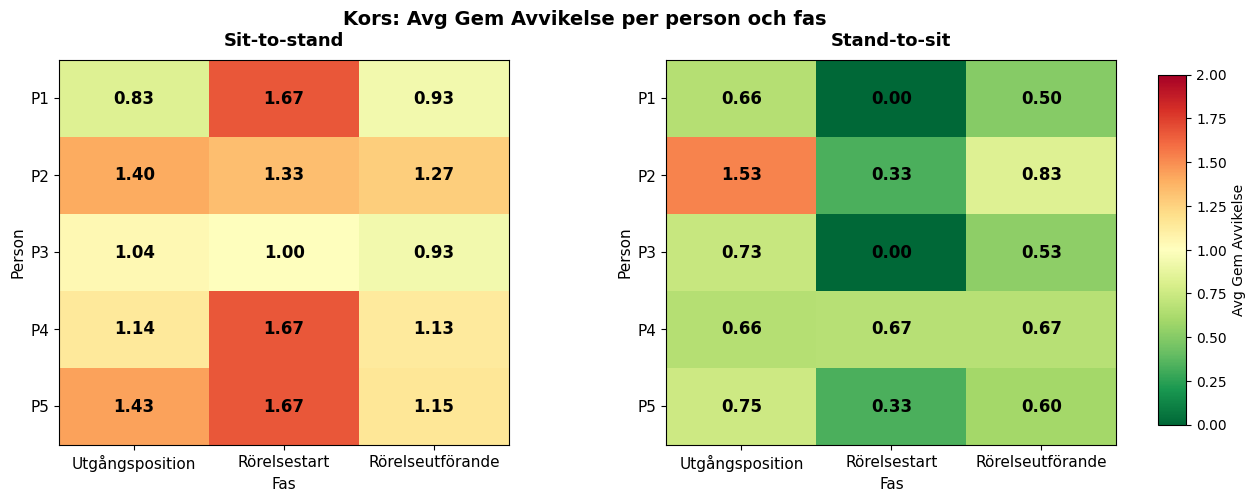

Sparad: ../data/processed/OMA_Score/Heatmaps/heatmap_avvikelse_kors.png


In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Kors: Avg Gem Avvikelse per person och fas', fontsize=14, fontweight='bold')
im1 = plot_heatmap(pivots[('Kors', '2a_1')], 'Sit-to-stand', axes[0])
im2 = plot_heatmap(pivots[('Kors', '2a_2')], 'Stand-to-sit', axes[1])
fig.subplots_adjust(right=0.88, wspace=0.35)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
fig.colorbar(im1, cax=cbar_ax, label='Avg Gem Avvikelse')
out =  OUT_DIR/ 'heatmap_avvikelse_kors.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sparad: {out}')

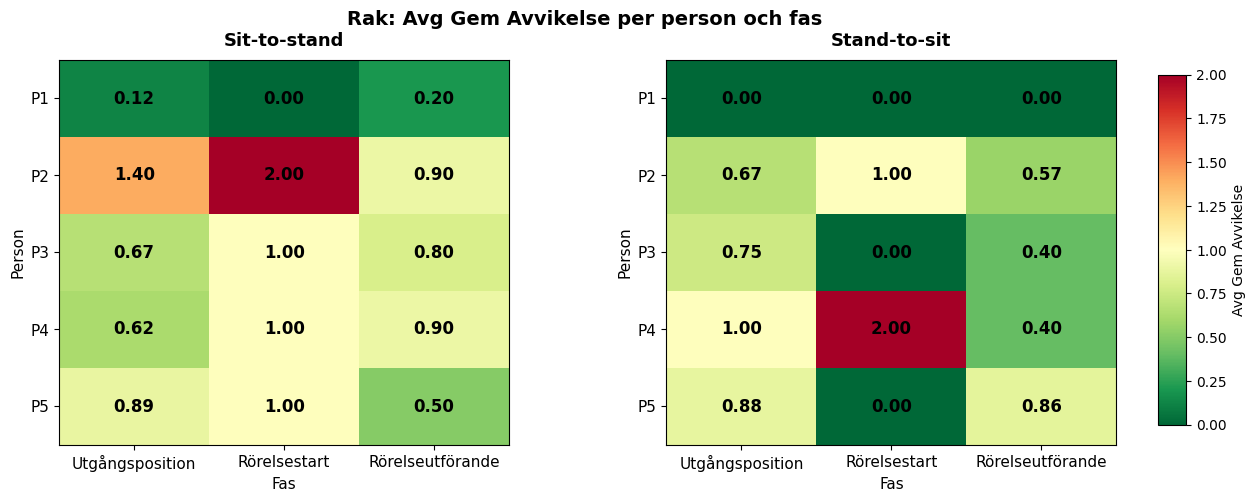

Sparad: ../data/processed/OMA_Score/Heatmaps/heatmap_avvikelse_rak.png


In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Rak: Avg Gem Avvikelse per person och fas', fontsize=14, fontweight='bold')
im1 = plot_heatmap(pivots[('Rak', '2a_1')], 'Sit-to-stand', axes[0])
im2 = plot_heatmap(pivots[('Rak', '2a_2')], 'Stand-to-sit', axes[1])
fig.subplots_adjust(right=0.88, wspace=0.35)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
fig.colorbar(im1, cax=cbar_ax, label='Avg Gem Avvikelse')
out = OUT_DIR / 'heatmap_avvikelse_rak.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sparad: {out}')

The **Kors** condition shows consistently higher avvikelse across all persons and phases compared to **Rak**, suggesting that crossed arms increase movement deviation.

 **Rörelsestart** is the most affected phase in both conditions.

The **Rak stand-to-sit** movement has the lowest avvikelse overall, indicating it is the most consistent movement across participants.

---

## Gem Säker per person och fas

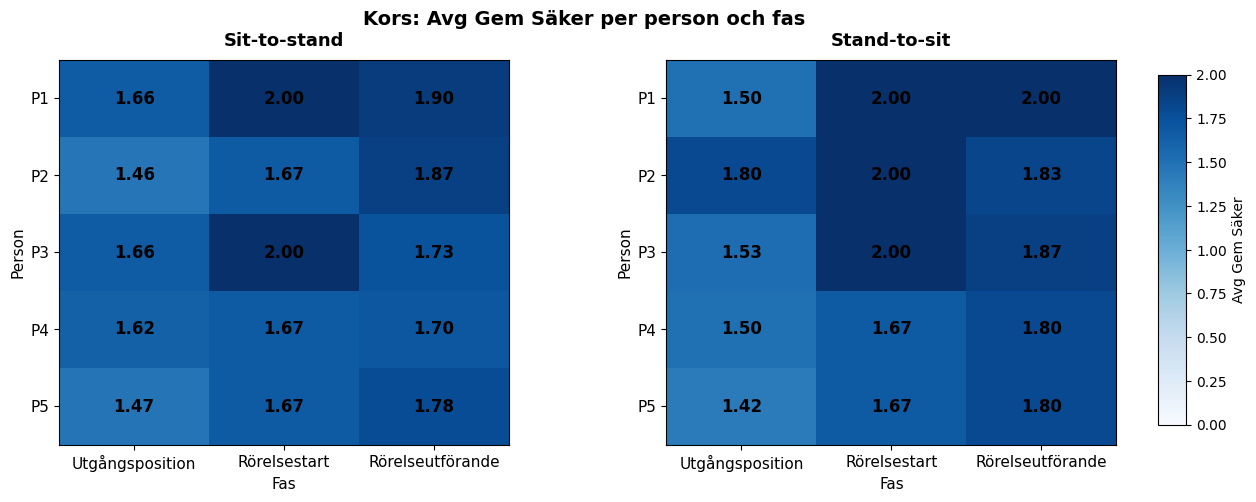

Sparad: ../data/processed/OMA_Score/Heatmaps/heatmap_saker_kors.png


In [82]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Kors: Avg Gem Säker per person och fas', fontsize=14, fontweight='bold')
im1 = plot_heatmap(pivots_saker[('Kors', '2a_1')], 'Sit-to-stand', axes[0], cmap=plt.cm.Blues)
im2 = plot_heatmap(pivots_saker[('Kors', '2a_2')], 'Stand-to-sit',  axes[1], cmap=plt.cm.Blues)
fig.subplots_adjust(right=0.88, wspace=0.35)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
fig.colorbar(im1, cax=cbar_ax, label='Avg Gem Säker')
out = OUT_DIR / 'heatmap_saker_kors.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sparad: {out}')

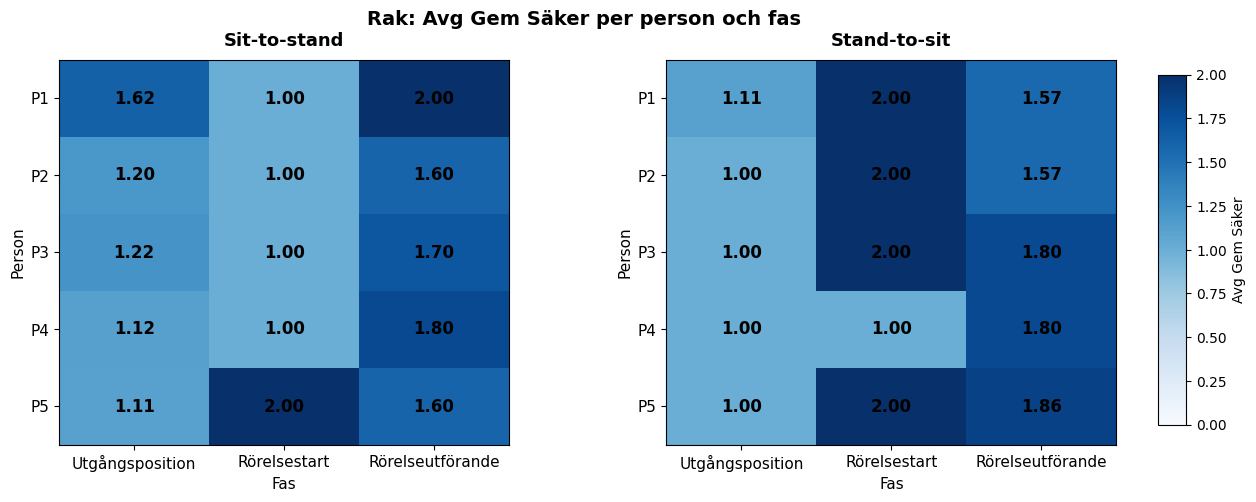

Sparad: ../data/processed/OMA_Score/Heatmaps/heatmap_saker_rak.png


In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Rak: Avg Gem Säker per person och fas', fontsize=14, fontweight='bold')
im1 = plot_heatmap(pivots_saker[('Rak', '2a_1')], 'Sit-to-stand', axes[0], cmap=plt.cm.Blues)
im2 = plot_heatmap(pivots_saker[('Rak', '2a_2')], 'Stand-to-sit',  axes[1], cmap=plt.cm.Blues)
fig.subplots_adjust(right=0.88, wspace=0.35)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
fig.colorbar(im1, cax=cbar_ax, label='Avg Gem Säker')
out = OUT_DIR / 'heatmap_saker_rak.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sparad: {out}')

The **Kors** condition shows more consistent certainty across persons and phases.

In **Rak**, certainty varies more, particularly in **Utgångsposition**, suggesting raters found the starting position harder to assess with straight arms.

**Rörelsestart** tends to be the most certain phase in both conditions.

---

## Per aspect

In [91]:
RAW_KORS = Path('../data/processed/OMA_Score/OMA_Score_Kors.csv')
RAW_RAK  = Path('../data/processed/OMA_Score/OMA_Score_Rak.csv')

raw_kors = pd.read_csv(RAW_KORS)
raw_rak  = pd.read_csv(RAW_RAK)
for col in ['Gem_Avvikelse', 'Gem_Säker']:
    raw_kors[col] = pd.to_numeric(raw_kors[col], errors='coerce')
    raw_rak[col]  = pd.to_numeric(raw_rak[col],  errors='coerce')

PHASE_ORDER = ['f1', 'f2', 'f3']

def build_aspect_pivot(df, rorelse_id, values='Gem_Avvikelse'):
    sub = df[df['RörelseId'] == rorelse_id].copy()
    sub['label'] = sub['PhaseId'] + '-A' + sub['AspektId'].astype(str)
    col_order = (sub.sort_values(['PhaseId', 'AspektId'])
                    .drop_duplicates('label')['label'].tolist())
    pivot = sub.pivot(index='PersonId', columns='label', values=values)
    pivot = pivot.reindex(index=list(PERSON_LABELS), columns=col_order)
    pivot.index = [PERSON_LABELS[p] for p in pivot.index]
    pivot.index.name = 'Person'
    pivot.columns.name = None
    return pivot, col_order

print('Raw data loaded')
print(f'Kors: {len(raw_kors)} rows')
print(f'Rak: {len(raw_rak)} rows')

Raw data loaded
Kors: 225 rows
Rak: 225 rows


In [90]:
def plot_aspect_heatmap(pivot, col_order, title, ax, vmin=0, vmax=2, cmap=plt.cm.RdYlGn_r):
    data = pivot.values.astype(float)
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=10)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            if not pd.isna(val):
                ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                        fontsize=6, fontweight='bold', color='black')

    phases = [c.split('-')[0] for c in col_order]
    for j in range(1, len(phases)):
        if phases[j] != phases[j-1]:
            ax.axvline(j - 0.5, color='white', linewidth=2)

    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('Aspekt (fas-nummer)', fontsize=9)
    ax.set_ylabel('Person', fontsize=9)
    return im


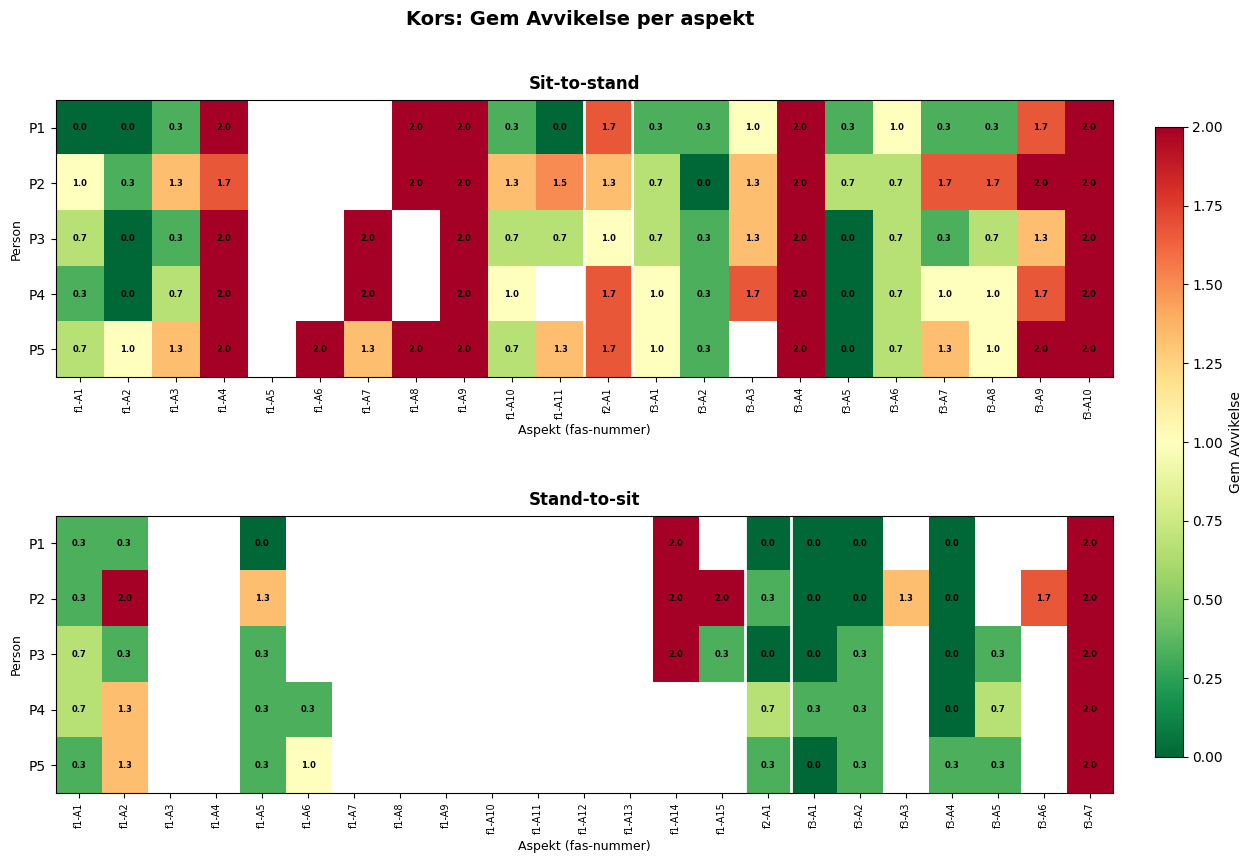

Sparad: ../data/processed/OMA_Score/Heatmaps/heatmap_aspect_avvikelse_kors.png


In [85]:
pivot_kors_21_avv, col_kors_21 = build_aspect_pivot(raw_kors, '2a_1')
pivot_kors_22_avv, col_kors_22 = build_aspect_pivot(raw_kors, '2a_2')
fig_w = max(14, max(len(col_kors_21), len(col_kors_22)) * 0.55)
fig, axes = plt.subplots(2, 1, figsize=(fig_w, 9))
fig.suptitle('Kors: Gem Avvikelse per aspekt', fontsize=14, fontweight='bold')
im1 = plot_aspect_heatmap(pivot_kors_21_avv, col_kors_21, 'Sit-to-stand', axes[0])
im2 = plot_aspect_heatmap(pivot_kors_22_avv, col_kors_22, 'Stand-to-sit',  axes[1])
fig.subplots_adjust(right=0.88, hspace=0.5)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
fig.colorbar(im1, cax=cbar_ax, label='Gem Avvikelse')
out = OUT_DIR / 'heatmap_aspect_avvikelse_kors.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sparad: {out}')

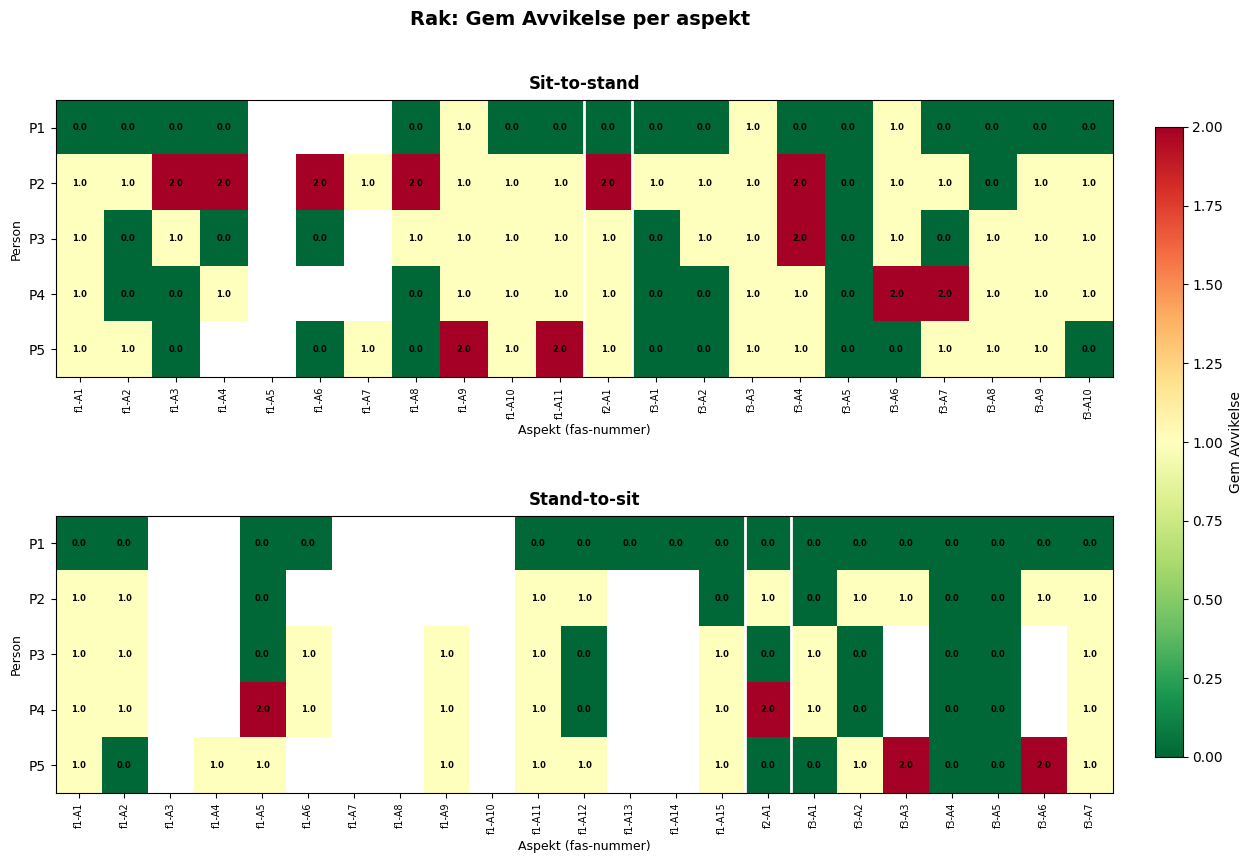

Sparad: ../data/processed/OMA_Score/Heatmaps/heatmap_aspect_avvikelse_rak.png


In [86]:
pivot_rak_21_avv, col_rak_21 = build_aspect_pivot(raw_rak, '2a_1')
pivot_rak_22_avv, col_rak_22 = build_aspect_pivot(raw_rak, '2a_2')
fig_w = max(14, max(len(col_rak_21), len(col_rak_22)) * 0.55)
fig, axes = plt.subplots(2, 1, figsize=(fig_w, 9))
fig.suptitle('Rak: Gem Avvikelse per aspekt', fontsize=14, fontweight='bold')
im1 = plot_aspect_heatmap(pivot_rak_21_avv, col_rak_21, 'Sit-to-stand', axes[0])
im2 = plot_aspect_heatmap(pivot_rak_22_avv, col_rak_22, 'Stand-to-sit',  axes[1])
fig.subplots_adjust(right=0.88, hspace=0.5)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
fig.colorbar(im1, cax=cbar_ax, label='Gem Avvikelse')
out = OUT_DIR / 'heatmap_aspect_avvikelse_rak.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sparad: {out}')

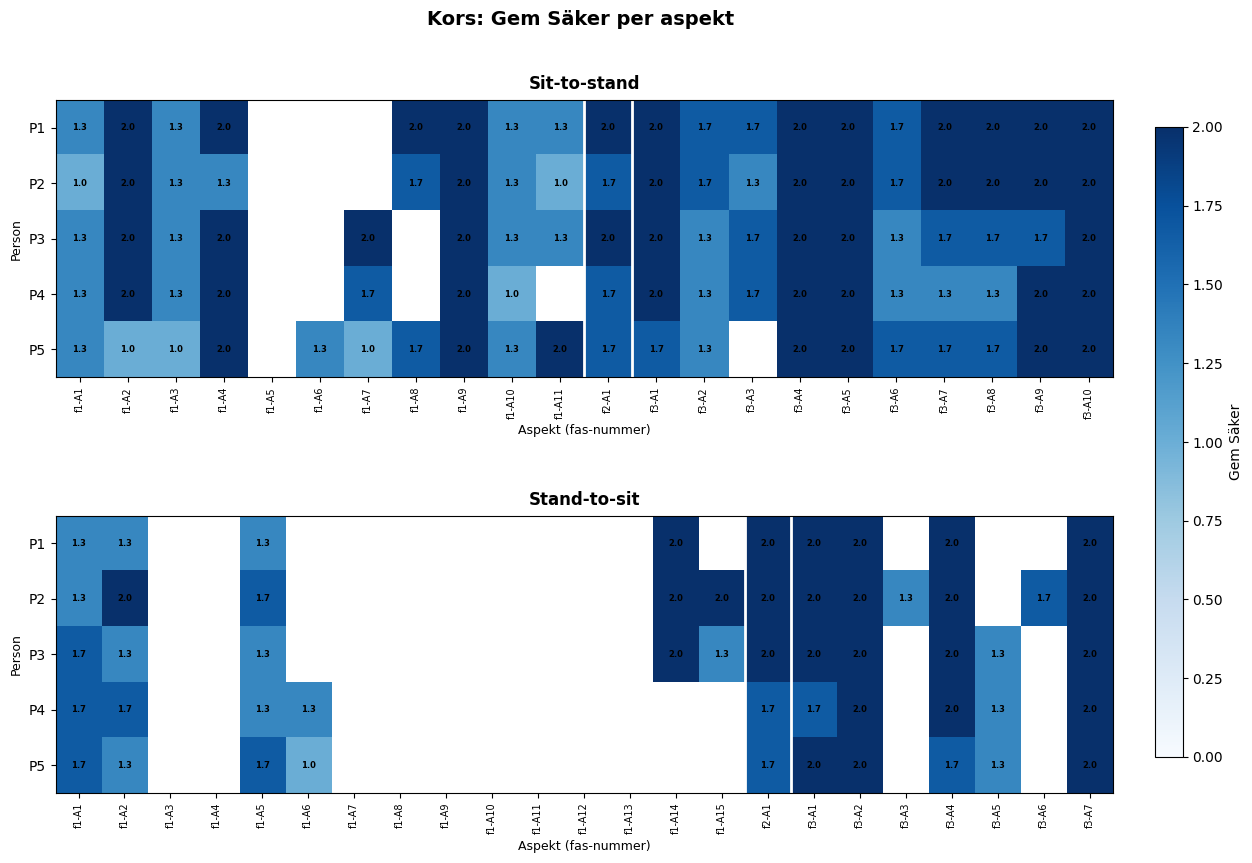

Sparad: ../data/processed/OMA_Score/Heatmaps/heatmap_aspect_saker_kors.png


In [87]:
pivot_kors_21_sak, _ = build_aspect_pivot(raw_kors, '2a_1', values='Gem_Säker')
pivot_kors_22_sak, _ = build_aspect_pivot(raw_kors, '2a_2', values='Gem_Säker')
fig_w = max(14, max(len(col_kors_21), len(col_kors_22)) * 0.55)
fig, axes = plt.subplots(2, 1, figsize=(fig_w, 9))
fig.suptitle('Kors: Gem Säker per aspekt', fontsize=14, fontweight='bold')
im1 = plot_aspect_heatmap(pivot_kors_21_sak, col_kors_21, 'Sit-to-stand', axes[0], cmap=plt.cm.Blues)
im2 = plot_aspect_heatmap(pivot_kors_22_sak, col_kors_22, 'Stand-to-sit',  axes[1], cmap=plt.cm.Blues)
fig.subplots_adjust(right=0.88, hspace=0.5)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
fig.colorbar(im1, cax=cbar_ax, label='Gem Säker')
out = OUT_DIR / 'heatmap_aspect_saker_kors.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sparad: {out}')

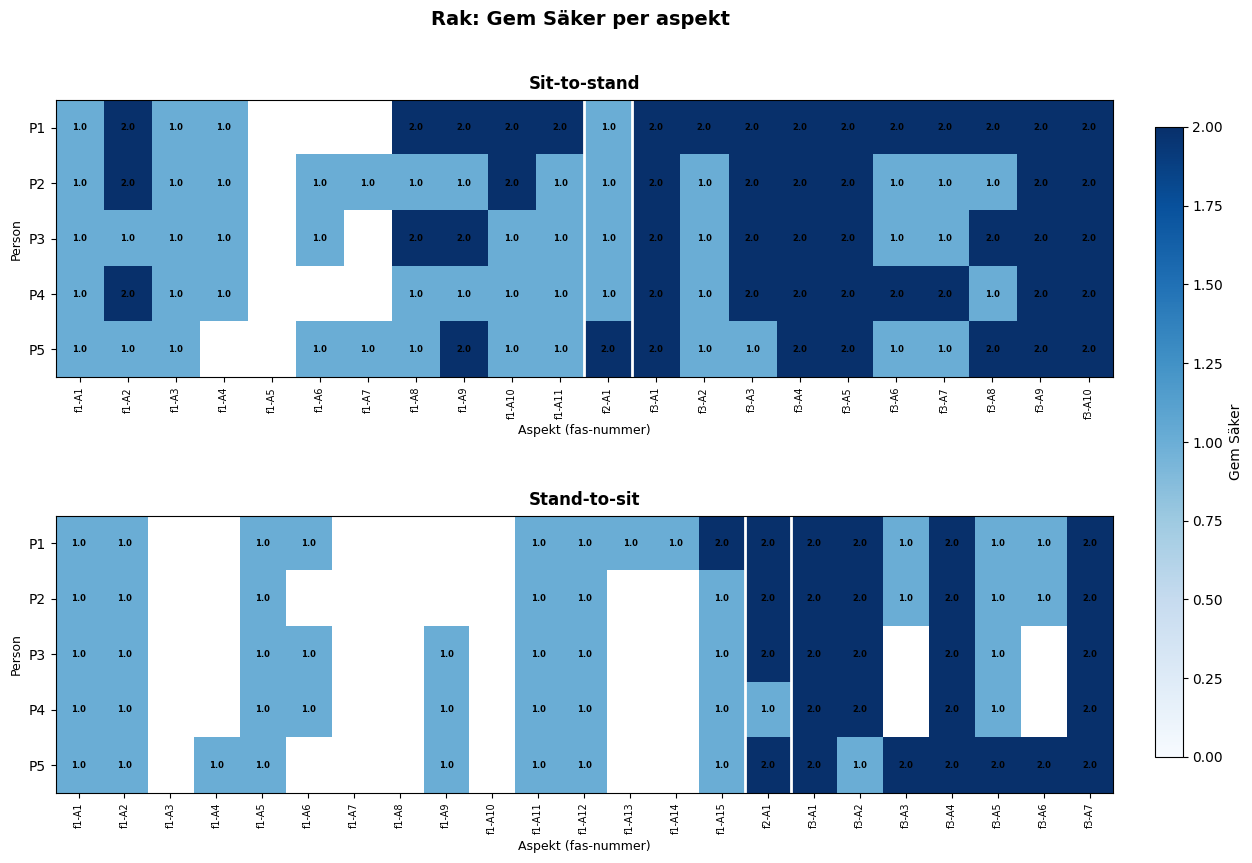

Sparad: ../data/processed/OMA_Score/Heatmaps/heatmap_aspect_saker_rak.png


In [88]:
pivot_rak_21_sak, _ = build_aspect_pivot(raw_rak, '2a_1', values='Gem_Säker')
pivot_rak_22_sak, _ = build_aspect_pivot(raw_rak, '2a_2', values='Gem_Säker')
fig_w = max(14, max(len(col_rak_21), len(col_rak_22)) * 0.55)
fig, axes = plt.subplots(2, 1, figsize=(fig_w, 9))
fig.suptitle('Rak: Gem Säker per aspekt', fontsize=14, fontweight='bold')
im1 = plot_aspect_heatmap(pivot_rak_21_sak, col_rak_21, 'Sit-to-stand', axes[0], cmap=plt.cm.Blues)
im2 = plot_aspect_heatmap(pivot_rak_22_sak, col_rak_22, 'Stand-to-sit',  axes[1], cmap=plt.cm.Blues)
fig.subplots_adjust(right=0.88, hspace=0.5)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
fig.colorbar(im1, cax=cbar_ax, label='Gem Säker')
out = OUT_DIR / 'heatmap_aspect_saker_rak.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sparad: {out}')